In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Thesis
import sys
sys.path.append("/content/drive/MyDrive/Thesis")

Mounted at /content/drive
/content/drive/MyDrive/Thesis


In [ ]:
pip install "sb3-contrib==2.3.0" "stable-baselines3==2.3.0"


Reason for being yanked: Loading broken with PyTorch 1.13
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 28.6 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.2.3
    Uninstalling gymnasium-1.2.3:
      Successfully uninstalled gymnasium-1.2.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.1 which is incompatible.


In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
#import gym
#from gym import spaces
from sb3_contrib import QRDQN
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor
from convAE import ConvAE
import gymnasium as gym
from gymnasium import spaces



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Load labeled and unlabeled data
X_labeled = np.load("X_labeled.npy")
y_labeled = np.load("y_labeled.npy")
X_unlabeled = np.load("X_unlabeled.npy")
y_unlabeled = np.load("y_unlabeled.npy")

# Load indices
labeled_indices = np.load("labeled_indices.npy")
unlabeled_indices = np.load("unlabeled_indices.npy")
train_split_size = np.load("train_split_size.npy")[0]

print(f"📊 Data loaded:")
print(f"   Labeled samples: {len(X_labeled):,}")
print(f"   Unlabeled samples: {len(X_unlabeled):,}")
print(f"   Original training size: {train_split_size:,}")

📊 Data loaded:
   Labeled samples: 4,142
   Unlabeled samples: 439,692
   Original training size: 443,834


In [ ]:
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

In [ ]:
# Load pretrained ConvAE (frozen) and AE stats
device = "cuda" if torch.cuda.is_available() else "cpu"
ae_model = ConvAE(feat_dim=X_unlabeled.shape[2], seq_len=X_unlabeled.shape[1], latent_dim=128)
ae_model.load_state_dict(torch.load("convAE_best.pth", map_location=device))
ae_model.to(device)
ae_model.eval()
for p in ae_model.parameters():
    p.requires_grad = False
print(f"✅ Loaded ConvAE on {device} (frozen for RecurrentPPO).")

stats = np.load("convAE_stats.npz")
ae_mean, ae_std = stats["mean_err"], stats["std_err"]
print(f"✅ AE normalization loaded: mean={ae_mean:.6f}, std={ae_std:.6f}")

✅ Loaded ConvAE on cuda (frozen for RecurrentPPO).
✅ AE normalization loaded: mean=0.126517, std=1.534175


In [ ]:


# Load thresholds
thresholds = np.load("convAE_thresholds.npz")
threshold_mild_raw = thresholds["threshold_k1_5_raw"]
threshold_conservative_raw = thresholds["threshold_k3_0_raw"]
threshold_mild_norm = thresholds["threshold_k1_5_norm"]
threshold_conservative_norm = thresholds["threshold_k3_0_norm"]

print(f"✅ Thresholds loaded:")
print(f"   Raw:        mild={threshold_mild_raw:.6f}, conservative={threshold_conservative_raw:.6f}")
print(f"   Normalized: mild={threshold_mild_norm:.6f}, conservative={threshold_conservative_norm:.6f}")

✅ Thresholds loaded:
   Raw:        mild=0.183164, conservative=0.274388
   Normalized: mild=0.036923, conservative=0.096384


In [ ]:
# ============================================================================
# STEP 1: Reconstruct chronological order
# ============================================================================
print("\n" + "="*70)
print("🔄 RECONSTRUCTING CHRONOLOGICAL ORDER")
print("="*70)



print(f"📊 Data loaded:")
print(f"   Labeled samples: {len(X_labeled):,}")
print(f"   Unlabeled samples: {len(X_unlabeled):,}")
print(f"   Original training size: {train_split_size:,}")

# Reconstruct X and y in chronological order
X_train_reconstructed = np.zeros((train_split_size, *X_labeled.shape[1:]), dtype=X_labeled.dtype)
y_train_reconstructed = np.zeros(train_split_size, dtype=y_labeled.dtype)

# Place data back at original positions
X_train_reconstructed[labeled_indices] = X_labeled
y_train_reconstructed[labeled_indices] = y_labeled
X_train_reconstructed[unlabeled_indices] = X_unlabeled
y_train_reconstructed[unlabeled_indices] = y_unlabeled

# Create supervision mask (1 = labeled/supervised, 0 = unlabeled/unsupervised)
supervision_mask = np.zeros(train_split_size, dtype=np.int8)
supervision_mask[labeled_indices] = 1  # These positions have supervision

print(f"\n✅ Reconstructed training data:")
print(f"   Shape: {X_train_reconstructed.shape}")
print(f"   Supervised positions: {np.sum(supervision_mask):,} ({np.sum(supervision_mask)/train_split_size*100:.2f}%)")
print(f"   Unsupervised positions: {np.sum(1-supervision_mask):,} ({np.sum(1-supervision_mask)/train_split_size*100:.2f}%)")

# Verify reconstruction
y_train_original = np.load("y_train_seq.npy")
if np.array_equal(y_train_reconstructed, y_train_original):
    print("✅ VERIFICATION PASSED: Reconstruction matches original!")
else:
    print("⚠️  WARNING: Reconstruction mismatch detected!")

print("="*70 + "\n")


🔄 RECONSTRUCTING CHRONOLOGICAL ORDER
📊 Data loaded:
   Labeled samples: 4,142
   Unlabeled samples: 439,692
   Original training size: 443,834

✅ Reconstructed training data:
   Shape: (443834, 32, 47)
   Supervised positions: 4,142 (0.93%)
   Unsupervised positions: 439,692 (99.07%)
✅ VERIFICATION PASSED: Reconstruction matches original!



In [ ]:

# ============================================================================
# STEP 2: DQN Environment (Chronological Sequential)
# ============================================================================

class QRDQNAEEnvChronological(gym.Env):
    """
    Sequential environment that processes windows in chronological order.
    Uses supervision_mask to determine which positions have labels.
    """
    def __init__(self, X_train, y_train, supervision_mask, ae_model,
                 embeddings, lambda_int=1.0, max_steps=2000):
        super().__init__()
        self.X_train = X_train
        self.y_train = y_train
        self.supervision_mask = supervision_mask  # 1=supervised, 0=unsupervised
        self.ae_model = ae_model
        self.device = next(ae_model.parameters()).device
        self.lambda_int = lambda_int
        self.max_steps = max_steps
        self.steps = 0
        self.idx = 0
        self.embeddings = embeddings


        self.episode_count = 0

        emb_dim = self.embeddings.shape[1]
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(emb_dim + 1,),
            dtype=np.float32
        )
        self.action_space = spaces.Discrete(2)  # 0 = normal, 1 = anomaly

        # Statistics
        n_supervised = np.sum(supervision_mask)
        n_unsupervised = len(supervision_mask) - n_supervised
        print(f"\n🔹 Environment initialized:")
        print(f"   Total windows: {len(X_train):,}")
        print(f"   Supervised: {n_supervised:,} ({n_supervised/len(X_train)*100:.2f}%)")
        print(f"   Unsupervised: {n_unsupervised:,} ({n_unsupervised/len(X_train)*100:.2f}%)")


    def _ae_error(self, x):
        """Compute normalized reconstruction error."""
        with torch.no_grad():
            x = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(self.device)
            recon = self.ae_model(x)
            loss = F.mse_loss(recon, x, reduction="mean").item()
        # Return z-score normalized error (no tanh)
        norm = (loss - ae_mean) / (ae_std + 1e-8)
        return max(0, norm)

    def reset(self, *, seed=45, options=None):
        """
        Reset with SYSTEMATIC starting positions for guaranteed coverage.
        Each episode starts exactly max_steps positions ahead of the previous.
        """
        super().reset(seed=seed)
        self.steps = 0

        self.idx = (self.episode_count * self.max_steps) % len(self.X_train)
        self.episode_count += 1

        # Log coverage progress periodically
        if self.episode_count % 50 == 0:
            chunks_covered = self.episode_count % (len(self.X_train) // self.max_steps)
            if chunks_covered == 0:
                chunks_covered = len(self.X_train) // self.max_steps
            total_chunks = len(self.X_train) // self.max_steps
            coverage_pct = min(100, (chunks_covered / total_chunks) * 100)
            pass_num = (self.episode_count // total_chunks) + 1
            print(f"📊 Episode {self.episode_count}: Starting at idx={self.idx:,} | "
                  f"Pass #{pass_num} | Coverage: {coverage_pct:.1f}%")

        emb = self.embeddings[self.idx]
        err = np.array([self._ae_error(self.X_train[self.idx])])
        obs = np.concatenate([emb, err]).astype(np.float32)
        return obs, {}


    # def step(self, action):
    #     """Take action on current window, move to next chronologically."""
    #     self.steps += 1

    #     # Current window
    #     x = self.X_train[self.idx]
    #     true_label = self.y_train[self.idx]
    #     is_supervised = self.supervision_mask[self.idx]

    #     # Compute reconstruction error
    #     err = self._ae_error(x)

    #     # ========== REWARD CALCULATION ==========

    #     # External reward (only for supervised positions)
    #     if is_supervised == 1:
    #         # We have ground truth label
    #         external_reward = 1.0 if action == true_label else -0.5
    #     else:
    #         # No supervision - no external reward
    #         external_reward = 0.0

    #     # Intrinsic reward (based on reconstruction error)
    #     # Encourage anomaly prediction when error is high
    #     if action == 1:  # Predicted anomaly
    #         intrinsic_reward = self.lambda_int * err
    #         # Penalize weak false positives
    #         if err < threshold_mild_norm:
    #             intrinsic_reward -= 0.5
    #     else:  # Predicted normal
    #         intrinsic_reward = 0.0

    #     # Total reward
    #     reward = external_reward + intrinsic_reward
    #     reward = np.clip(reward, -5, 5)

    #     # ========== MOVE TO NEXT WINDOW (CHRONOLOGICALLY) ==========
    #     self.idx = (self.idx + 1) % len(self.X_train)

    #     # Next observation
    #     next_emb = self.embeddings[self.idx]
    #     next_err = np.array([self._ae_error(self.X_train[self.idx])])
    #     obs = np.concatenate([next_emb, next_err]).astype(np.float32)

    #     done = self.steps >= self.max_steps

    #     return obs, reward, done, False, {}

    def step(self, action):
        """Take action on current window, move to next chronologically."""
        self.steps += 1

        # Current window
        x = self.X_train[self.idx]
        true_label = self.y_train[self.idx]  # Will be 1 if supervised
        is_supervised = self.supervision_mask[self.idx]

        # Compute reconstruction error
        err = self._ae_error(x)

        # ========== REWARD CALCULATION ==========

        # 1. EXTERNAL REWARD (supervised positions only)
        if is_supervised == 1:
            # Supervised windows are ALWAYS anomalies (true_label = 1)
            if action == 1:
                # Correct! Agent detected the labeled anomaly
                external_reward = 2.0
            else:  # action == 0
                # FALSE NEGATIVE - missed a confirmed attack!
                external_reward = -2.0  # Harsh penalty
        else:
            # Unsupervised - no ground truth available
            external_reward = 0.0

        # 2. INTRINSIC REWARD (confidence-based, smooth shaping)
        if action == 1:  # Predicted anomaly
            # Reward proportional to reconstruction error
            # High error → high confidence → high reward
            confidence_score = (err - threshold_mild_norm) / (threshold_conservative_norm - threshold_mild_norm + 1e-8)
            confidence_score = np.clip(confidence_score, -1, 1)

            intrinsic_reward = self.lambda_int * confidence_score

        else:  # Predicted normal
            # Reward when error is LOW (confident it's normal)
            # Low error → high confidence → high reward
            confidence_score = (threshold_mild_norm - err) / (threshold_mild_norm + 1e-8)
            confidence_score = np.clip(confidence_score, -1, 1)

            intrinsic_reward = self.lambda_int * confidence_score * 0.5

        # 3. TOTAL REWARD
        reward = external_reward + intrinsic_reward
        reward = np.clip(reward, -5, 5)

        # ========== MOVE TO NEXT WINDOW ==========
        self.idx = (self.idx + 1) % len(self.X_train)

        next_emb = self.embeddings[self.idx]
        next_err = np.array([self._ae_error(self.X_train[self.idx])])
        obs = np.concatenate([next_emb, next_err]).astype(np.float32)

        done = self.steps >= self.max_steps

        return obs, reward, done, False, {}

# ============================================================================
# STEP 3: Precompute embeddings
# ============================================================================

def compute_embeddings(X):
    """Compute embeddings for all windows."""
    with torch.no_grad():
        tensors = torch.tensor(X, dtype=torch.float32).to(device)
        embeds = ae_model.encode(tensors).cpu().numpy()
    return embeds

print("🔹 Precomputing embeddings for reconstructed data...")
embeddings_train = compute_embeddings(X_train_reconstructed)
print(f"✅ Embeddings computed: {embeddings_train.shape}")


# ============================================================================
# STEP 4: Create VecEnv + QR-DQN 
# ============================================================================

def make_env(rank):
    def _init():
        env = QRDQNAEEnvChronological(
            X_train_reconstructed, 
            y_train_reconstructed, 
            supervision_mask,
            ae_model,
            embeddings_train,
            lambda_int=0.8, 
            max_steps=2000
        )
        return Monitor(env, f"logs/env_{rank}")
    return _init

num_envs = 1
vec_env = DummyVecEnv([make_env(i) for i in range(num_envs)])
vec_env = VecNormalize(vec_env, norm_obs=True, norm_reward=True, clip_obs=10.)

# Policy kwargs (deeper for distributional modeling)
policy_kwargs = dict(
    net_arch=[512, 256]  # QR-DQN benefits from slightly deeper nets
)

model = QRDQN(
    "MlpPolicy",
    vec_env,
    verbose=1,
    learning_rate=1e-4,
    buffer_size=150_000,         
    learning_starts=5_000,
    batch_size=64,
    tau=1.0,
    gamma=0.99,
    train_freq=4,
    target_update_interval=1_000,
    exploration_fraction=0.1,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    policy_kwargs=policy_kwargs,
    tensorboard_log="logs_qrdqn_ae_chronological/"
)

print("\n" + "="*70)
print("🚀 Starting QR-DQN training with chronological data")
print("="*70 + "\n")



# ============================================================================
# STEP 5: Train QR-DQN
# ============================================================================

model.learn(total_timesteps=500_000)  # More timesteps recommended for distributional methods
model.save("qrdqn_ae_chronological")
vec_env.save("vec_normalize_qrdqn_chronological.pkl")

print("\n✅ Training complete! Chronological QR-DQN model saved.")
print("   Model: qrdqn_ae_chronological.zip")
print("   VecNormalize: vec_normalize_qrdqn_chronological.pkl")

Streaming output truncated to the last 5000 lines.
|    ep_rew_mean          | 897          |
| time/                   |              |
|    fps                  | 161          |
|    iterations           | 3670         |
|    time_elapsed         | 2903         |
|    total_timesteps      | 469760       |
| train/                  |              |
|    approx_kl            | 0.0098199705 |
|    clip_fraction        | 0.0109       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.013       |
|    explained_variance   | 0.14161712   |
|    learning_rate        | 0.0001       |
|    loss                 | 0.000402     |
|    n_updates            | 36690        |
|    policy_gradient_loss | -0.00714     |
|    value_loss           | 0.0012       |
------------------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 2e+03        |
|    ep_rew_mean          | 897          |
| t

📊 Evaluating on test set...
Running inference...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


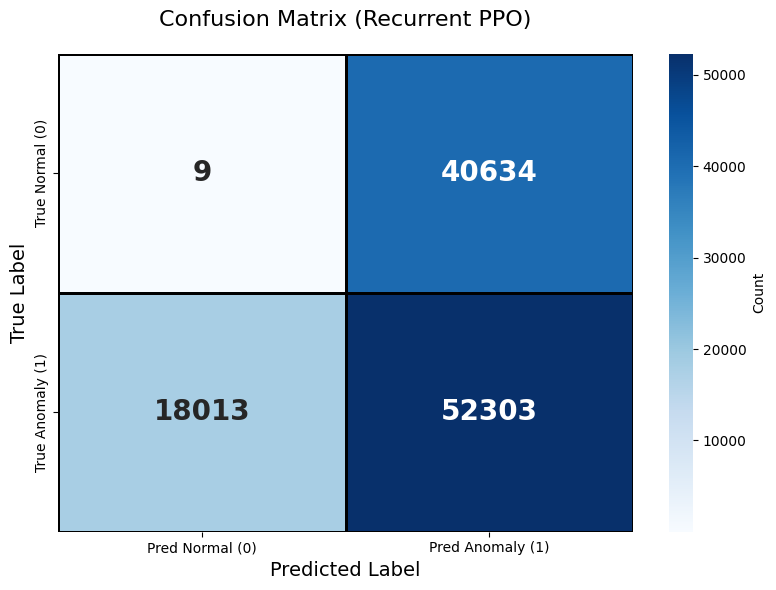


Precision : 0.5628
Recall    : 0.7438
F1-Score  : 0.6408
AUC       : 0.6302
TP: 52,303 | FP: 40,634 | FN: 18,013 | TN: 9


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


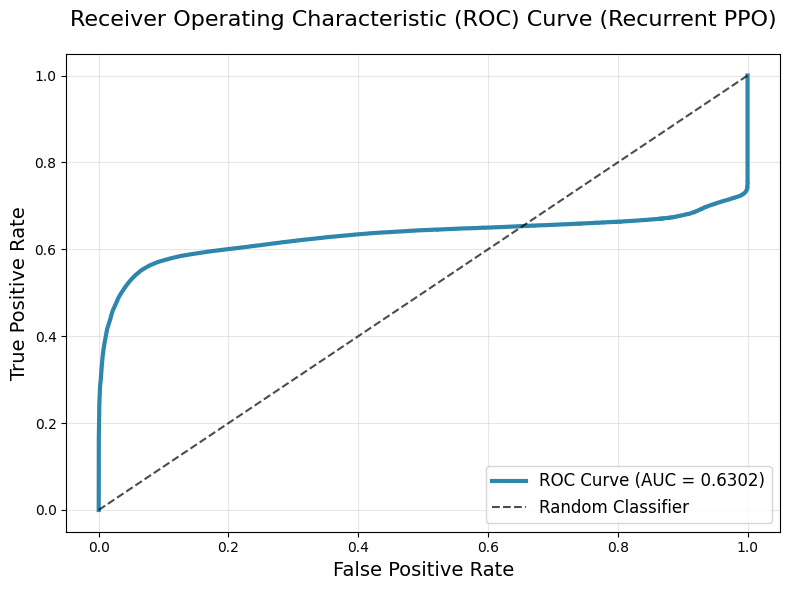

✅ Evaluation complete.


In [ ]:
# Evaluation for Quantile Regression DQN (QR-DQN)
print("📊 Evaluating QR-DQN...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)


# Load test data
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")  # binary: 0 = normal, 1 = anomaly


# Reuse observation creation function (same as training)
def make_obs_array(X_windows):
    obs_list = []
    with torch.no_grad():
        for x in X_windows:
            t = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)
            emb = ae_model.encode(t).cpu().numpy().flatten()
            recon = ae_model(t)
            loss = F.mse_loss(recon, t, reduction="mean").item()
            err = np.tanh((loss - ae_mean) / (ae_std + 1e-8))
            err = float(max(0.0, err))
            obs = np.concatenate([emb, [err]]).astype(np.float32)
            obs_list.append(obs)
    return np.array(obs_list)

print("Preparing test observations...")
obs_test = make_obs_array(X_test)

# === Inference for QR-DQN ===
y_pred = []
y_probs = []
deterministic = True

print("Running inference...")
for obs in obs_test:
    obs_reshaped = obs.reshape(1, -1)

    # Deterministic action (argmax over mean quantile)
    action, _ = model.predict(obs_reshaped, deterministic=deterministic)
    y_pred.append(int(action[0]))

    # Get probability-like score for anomaly (action=1)
    with torch.no_grad():
        obs_tensor = torch.as_tensor(obs_reshaped, dtype=torch.float32).to(device)

        # ─── Correct access for sb3-contrib QRDQN ───
        quantiles = model.policy.quantile_net(obs_tensor)   # [1, 200, 2]

        # Average across quantiles → approximate expected Q-value
        q_mean = quantiles.mean(dim=1)                       # [1, 2]

        probs = F.softmax(q_mean, dim=1)
        prob_anomaly = probs[0, 1].item()                    # probability of anomaly (action 1)
        y_probs.append(prob_anomaly)

y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

# === Metrics ===
cm = confusion_matrix(y_test, y_pred)  # [[TN, FP], [FN, TP]]
tn, fp, fn, tp = cm.ravel()

precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_probs)

# === Heatmap Confusion Matrix (Consistent Professional Style) ===
cm_df = pd.DataFrame(
    cm,
    index=['True Normal (0)', 'True Anomaly (1)'],
    columns=['Pred Normal (0)', 'Pred Anomaly (1)']
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black',
            cbar_kws={'label': 'Count'}, annot_kws={"size": 20, "weight": "bold"})
plt.title('Confusion Matrix (QR-DQN)', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.tight_layout()
plt.show()

# === Print Metrics ===
print(f"\nPrecision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"AUC       : {auc:.4f}")
print(f"TP: {tp:,} | FP: {fp:,} | FN: {fn:,} | TN: {tn:,}")

# === ROC Curve ===
fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})', linewidth=3, color='#2E86AB')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.7)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) Curve (QR-DQN)', fontsize=16, pad=20)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ QR-DQN Evaluation complete.")